In [2]:
import sys
sys.path.insert(0, "/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks/desi_pv_mocks")

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from config import load_config 
cfg=load_config('../config_files/mock_config_v2.1.yaml')
CONFIG = cfg.CONFIG

from fp_full import load_fp_catalog, load_spec_data

cosmo = FlatLambdaCDM(H0=100., Om0=0.3151)

In [ ]:
pwd

'/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks/notebooks'

In [17]:
spec   = load_spec_data(CONFIG.spec_csv, usecols=CONFIG.spec_keys)
#spec   = load_spec_data(CONFIG.spec_csv, usecols=None)
d_data = load_fp_catalog(CONFIG.data_fp_full)
print(len(d_data))
print(d_data.columns)
print(spec.columns)


15:45:13  INFO      spec : 1835524 → 1835524 entries after cut on zwarn == 0
15:45:15  INFO      FP catalogue : 229842 galaxies total
15:45:15  INFO      FP catalogue : 187395 calibrators kept


187395
Index(['targetid', 'ra', 'dec', 'zcmb', 'ppxf_vdisp', 'ppxf_vdisp_err',
       'zcmb_group', 'r', 'er', 'i', 'ei', 's', 'es', 'FPcalibrator', 'Sn'],
      dtype='str')
Index(['survey', 'program', 'healpix', 'targetid', 'z', 'zwarn', 'morphtype',
       'sersic', 'sersic_ivar', 'flux_g', 'flux_r', 'flux_z', 'mag_g', 'mag_r',
       'mag_z', 'BA_ratio', 'circ_radius', 'circ_radius_err', 'pos_angle'],
      dtype='str')


In [18]:
d_data = d_data.merge(spec, how="inner", on=["targetid"]) 
print(len(d_data))
print(d_data.columns)

185700
Index(['targetid', 'ra', 'dec', 'zcmb', 'ppxf_vdisp', 'ppxf_vdisp_err',
       'zcmb_group', 'r', 'er', 'i', 'ei', 's', 'es', 'FPcalibrator', 'Sn',
       'survey', 'program', 'healpix', 'z', 'zwarn', 'morphtype', 'sersic',
       'sersic_ivar', 'flux_g', 'flux_r', 'flux_z', 'mag_g', 'mag_r', 'mag_z',
       'BA_ratio', 'circ_radius', 'circ_radius_err', 'pos_angle'],
      dtype='str')


(10.0, 20.0)

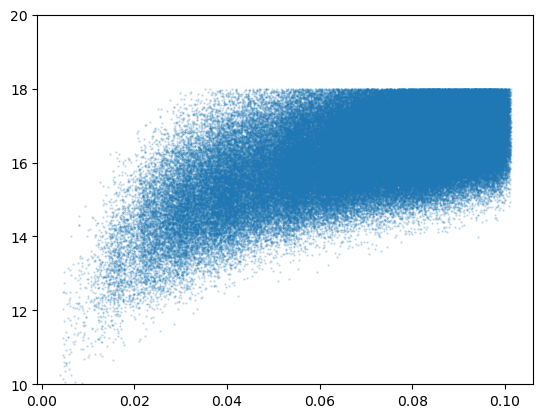

In [21]:
plt.plot(d_data['zcmb'], d_data['mag_r'], '.', ms=1, alpha=0.3)
plt.ylim(10, 20)

In [5]:
m_data = fits.open(CONFIG.mock_fp_full_data.format(phase=0, real=0))[1].data
#m_rand = fits.open(cfg.mock_fp_clus_rand.format(phase=1))[1].data
m_data.names, m_data.size

(['RA',
  'DEC',
  'ZOBS',
  'ZCOS',
  'vx',
  'vy',
  'vz',
  'r',
  'er',
  's',
  'es',
  'i',
  'ei',
  'Sn',
  'LOGDIST_TRUE',
  'LOGDIST',
  'LOGDIST_ERR',
  'LOGDIST_ALPHA',
  'LOGDIST_CORR',
  'LOGDIST_CORR_ERR',
  'LOGDIST_CORR_ALPHA'],
 172825)

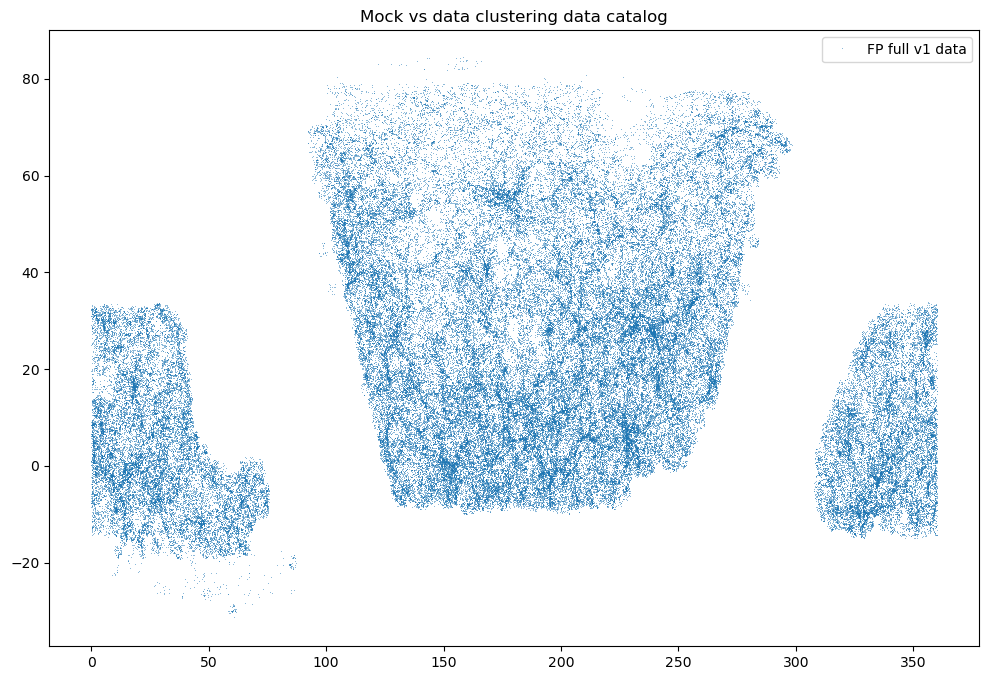

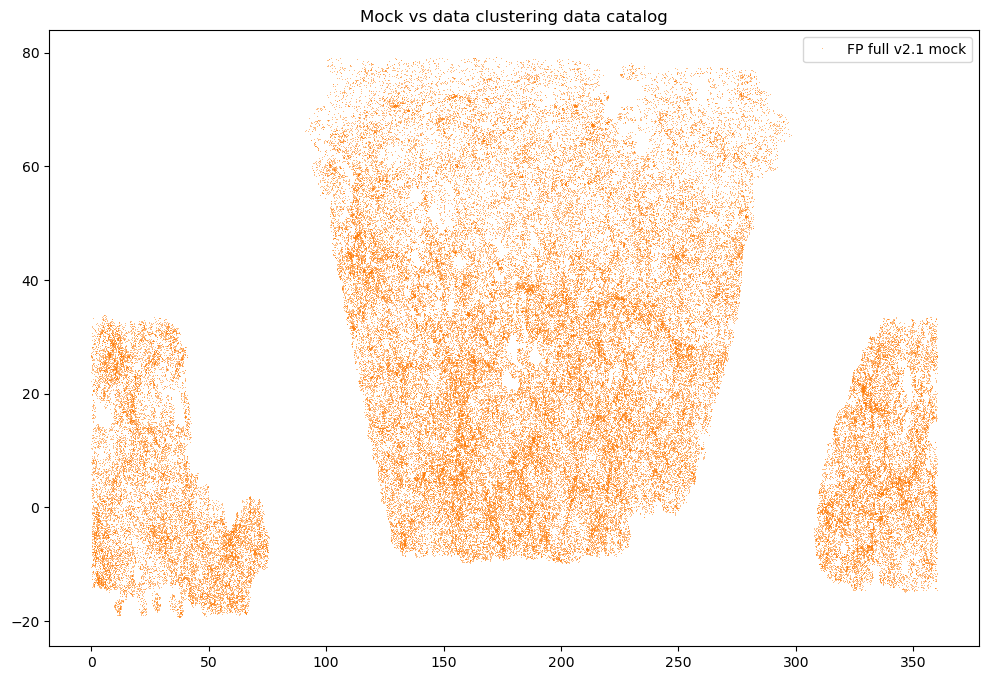

In [5]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['ra'], d_data['dec'], 'C0,', alpha=0.5, label=f'FP full {CONFIG.data_fp_full_version} data')
#plt.plot(m_data['RA'], m_data['DEC'], ',', alpha=0.5, label=f'FP full {CONFIG.version_fp_full} mock')
plt.title('Mock vs data clustering data catalog')
plt.legend()
plt.figure(figsize=(12, 8))
#plt.plot(d_data['ra'], d_data['dec'], ',', alpha=0.5, label=f'FP full {CONFIG.data_fp_full_version} data')
plt.plot(m_data['RA'], m_data['DEC'], 'C1,', alpha=0.5, label=f'FP full {CONFIG.version_fp_full} mock')
plt.title('Mock vs data clustering data catalog')
plt.legend()

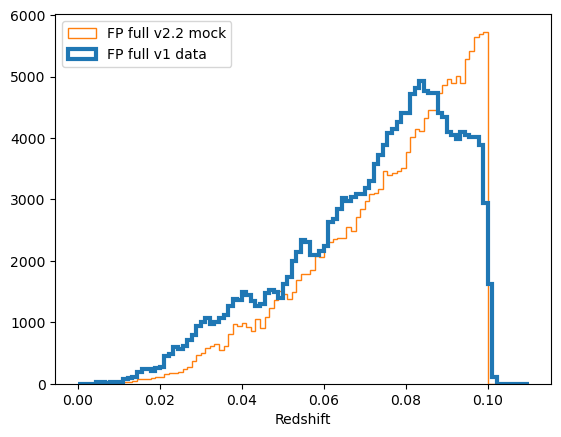

In [7]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(1):
        m_data_temp = fits.open(CONFIG.mock_fp_full_data.format(phase=phase, real=real))[1].data
        label = f'FP full {CONFIG.version_fp_full} mock' if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['ZOBS'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)
_=plt.hist(d_data['zcmb'], bins=zbins, histtype='step', lw=3,
           label=f'FP full {CONFIG.data_fp_full_version} data')

plt.xlabel('Redshift')
plt.legend()
plt.savefig(f'../plots/FP_full_nz_mock_{CONFIG.version_fp_full}_data_{CONFIG.data_fp_full_version}.pdf')